# HW2: Word2Vector
## Start

In [18]:
from idlelib.help_about import version
%run CBOW.ipynb
# start word2vec train process from here
txt_path = "data/"
save_vec_path = "model/word2vec/"
save_model_path = "model/"
train_path = "data/train/"

In [19]:
# load text
en_text = load_data(txt_path, version='en')
# create corpus
en_corpus = preprocess_text(en_text, language='en')
# create vocab
en_vocab = build_vocab(en_corpus)

In [20]:
# create training data
en_train_data = create_training_data(en_corpus, en_vocab, window_size=5)
random.shuffle(en_train_data)
torch.save(en_train_data, train_path+"en_train_data.pth")
# load train data
en_train_data = torch.load(train_path+"en_train_data.pth")
en_idx2word = {v:k for k,v in en_vocab.items()}
print(en_train_data[0], '\n', [en_idx2word.get(idx) for idx in en_train_data[0][0]], '\n', en_idx2word.get(en_train_data[0][1]))

D:\workdata\software\TEMP\USERTEMP\ipykernel_16584\1841669503.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  en_train_data = torch.load(train_path+"en_train_data.pth")


([0, 266, 844, 54, 253, 4, 4, 116, 475, 3456], 234) 
 ['UNK', 'report', 'says', 'since', 'change', 'taiwan', 'taiwan', 'authorities', 'taken', 'evasive'] 
 leadership


In [21]:
# train en model
model_en = CBOW(vocab_size=len(en_vocab), embedding_size=200).to(device)
# optimizer & loss function
optimizer, criterion = get_optim_and_loss(model_en, "SGD", "cross")
print(model_en, optimizer, criterion)

CBOW(
  (embedding): Embedding(11682, 100)
  (fc1): Linear(in_features=100, out_features=11682, bias=True)
) SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    momentum: 0.9
    nesterov: False
    weight_decay: 0
) CrossEntropyLoss()


Start en training...


100%|██████████| 1342/1342 [00:01<00:00, 981.25it/s] 


epoch 0, loss: 0.29288966178871834


100%|██████████| 1342/1342 [00:01<00:00, 1127.00it/s]


epoch 1, loss: 0.292120532102518


...

epoch 7, loss: 0.2875441274786629


100%|██████████| 1342/1342 [00:01<00:00, 1020.62it/s]


epoch 8, loss: 0.286789452322033


100%|██████████| 1342/1342 [00:01<00:00, 1009.67it/s]

epoch 9, loss: 0.286038185169197
Training finished


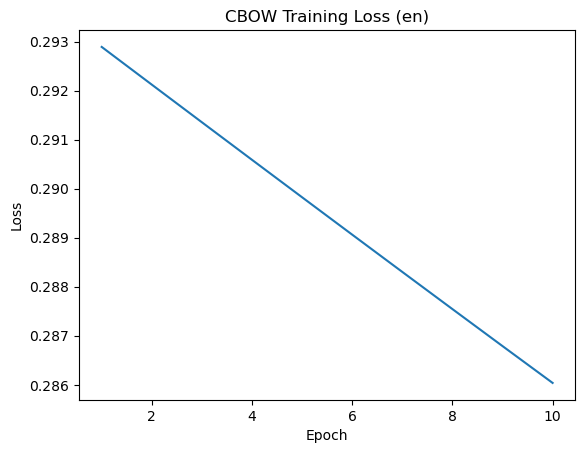

In [22]:
epochs = 100
# set train mode
model_en.train()
# start train
lossv_en = []
print('Start en training...')
train(model_en, en_train_data, optimizer, criterion, epochs, lossv_en, batch_size=32)
# plot 
plt.plot([epoch + 1 for epoch in range(0, epochs)], lossv_en)
plt.title('CBOW Training Loss (en)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

In [23]:
# save
save_model(model_en, save_model_path, version='en')
save_word_vectors(model_en, en_vocab, save_vec_path, version='en')

## 7. An Example Task to Use Trained Word Vectors
### Compute similarity among words

In [28]:
# load word vectors
word_vectors_en = load_word_vectors(save_vec_path, version="en")

top_n = 2
# find similar top n words
en_word = "report"
# english
top_similarities_en = find_similar_words(en_word, word_vectors_en, top_n)
print(f"Most similar top {top_n} words to '{en_word}':")
for word, similarity in top_similarities_en:
    print(f"{word}: {similarity:.3f}")

Most similar top 2 words to 'report':
quarantine: 1.393
admitting: 1.390
